# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing?

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Anastacia Oliynyk

**Date:** 9/2/26

In [2]:
# Your Phase 1 solution to the problem goes here.
from google.colab import files
uploaded = files.upload()

Saving airbnb_hw.csv to airbnb_hw.csv


Before coercion:
 count     30478
unique      511
top         150
freq       1481
Name: Price, dtype: object 

After coercion:
 count       30478.0
mean     163.589737
std      197.785454
min            10.0
25%            80.0
50%           125.0
75%           195.0
max         10000.0
Name: Price, dtype: Float64 

Total missings:
 0 



<Axes: >

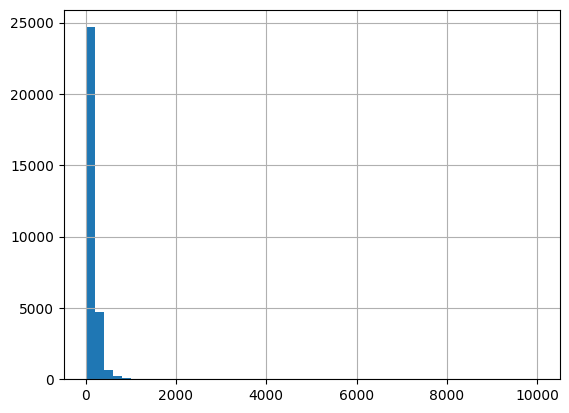

In [3]:
#1.1

import pandas as pd

df = pd.read_csv('airbnb_hw.csv')

var = 'Price'

print('Before coercion:\n', df[var].describe(), '\n')

df[var] = (
    df[var]
    .astype('string')                     #make values strings
    .str.replace(',', '', regex=False)    #removes comma from the text
    .str.strip()                          #removes extra spaces
)

df[var] = pd.to_numeric(df[var], errors='coerce')   #convert into numbers
df['Price_nan'] = df[var].isna()

print('After coercion:\n', df[var].describe(), '\n')
print('Total missings:\n', sum(df['Price_nan']), '\n')                   #count missing values

df[var].hist(bins=50)

# The Price variable was stored as a string because prices over $999 contained commas, like 1,112.
# I removed the commas and extra space, then converted Price to a numeric variable.
# After cleaning, there were 0 missing values.

In [6]:
from google.colab import files
uploaded = files.upload()

Saving mn_police_use_of_force.csv to mn_police_use_of_force (1).csv


In [10]:
#1.2

import pandas as pd

df = pd.read_csv('mn_police_use_of_force.csv')
var = 'subject_injury'

print(df[var].unique(), '\n')
print(df[var].value_counts(dropna=False), '\n')

df[var] = (
    df[var]
    .astype('string')
    .str.strip()
    .str.title()
)

print(df[var].value_counts(dropna=False), '\n')

missing_prop = df[var].isna().mean()

print('Proportion missing:', missing_prop)
print('Percent missing:', missing_prop * 100)

pd.crosstab(df[var], df['force_type'], dropna=False)

#About 76.2% of the subject_injury values are missing.
#this is a concern because more than three-fourths of the observations
#do not have injury information. i kept these values as missing rather
#than changing them to no, since a missing value doesnt always mean no injury happened.
#the crosstab shows a pattern in the missing data. some force types have much
#more missing injury info than others. for ex, less lethal and maximal restraint technique
#have all missing values while gun point display has much less. this suggests
#missingness might be related to the type of force used

[nan 'No' 'Yes'] 

subject_injury
NaN    9848
Yes    1631
No     1446
Name: count, dtype: int64 

subject_injury
<NA>    9848
Yes     1631
No      1446
Name: count, dtype: Int64 

Proportion missing: 0.7619342359767892
Percent missing: 76.19342359767892


force_type,Baton,Bodily Force,Chemical Irritant,Firearm,Gun Point Display,Improvised Weapon,Less Lethal,Less Lethal Projectile,Maximal Restraint Technique,Police K9 Bite,Taser
subject_injury,,,,,,,,,,,
No,0,1093,131,2,33,34,0,1,0,2,150
Yes,2,1286,41,0,44,40,0,2,0,44,172
<NA>,2,7051,1421,0,27,74,87,0,170,31,985


In [12]:
from google.colab import files
uploaded = files.upload()

Saving GSAF5.xls to GSAF5.xls


In [15]:
#2.1

import pandas as pd

df = pd.read_excel('GSAF5.xls')

df.head()

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
0,26th August,2026.0,Unprovoked,USA,Hawaii,"Ala Moana Beach Park, Oah'u",Surfing,Unknown Female,F,?,...,Tiger Shark,Keith Cowley: KHON: KITV:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,23rd August,2026.0,Unprovoked,USA,Florida,Boca Grande (island in the keys),Wading on a sandbar,David Daniel,M,43,...,Large shark,Keith Cowley: Todd Smith: NBC 6: ABC News:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,19th August,2026.0,Provoked,Reunion Island,Saint-Gilles-les-Baines,Outer Reef Roches Noires,Spearfishiong,Male,M,?,...,Bull shark 2.5m (8.2 ft),Todd Smith: Local Report Zinfos 874:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,11th August,2026.0,Provoked,Ireland,Waterford,Ardemore County,Fishing,Sebastian Achim,M,27,...,1.5m (5ft) Blue shark,Keith Cowley: David Bargh: Irish Times BBC Met...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,8th August,2026.0,Unprovoked,USA,Maine,Scarborough Beach Park,Operation of Rescue Torpedo,Greg Wilfert,M,71,...,Great White Shark,WGME: CBS News: Keith Cowley,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
#2.2

empty_cols = df.columns[df.isna().all()]
print('Empty columns:', empty_cols)
df = df.dropna(axis=1, how='all')
print(df.columns)

Empty columns: Index([], dtype='object')
Index(['Date', 'Year', 'Type', 'Country', 'State', 'Location', 'Activity',
       'Name', 'Sex', 'Age', 'Injury', 'Fatal Y/N', 'Time', 'Species ',
       'Source', 'pdf', 'href formula', 'href', 'Case Number', 'Case Number.1',
       'original order', 'Unnamed: 21', 'Unnamed: 22'],
      dtype='object')


Before cleaning:
 count    7115.000000
mean     1936.549122
std       269.943193
min         0.000000
25%      1948.000000
50%      1987.000000
75%      2010.000000
max      2026.000000
Name: Year, dtype: float64 

After cleaning: 
 count    7115.000000
mean     1936.549122
std       269.943193
min         0.000000
25%      1948.000000
50%      1987.000000
75%      2010.000000
max      2026.000000
Name: Year, dtype: float64 

Minimum year: 0.0
Maximum year: 2026.0


<Axes: xlabel='Year'>

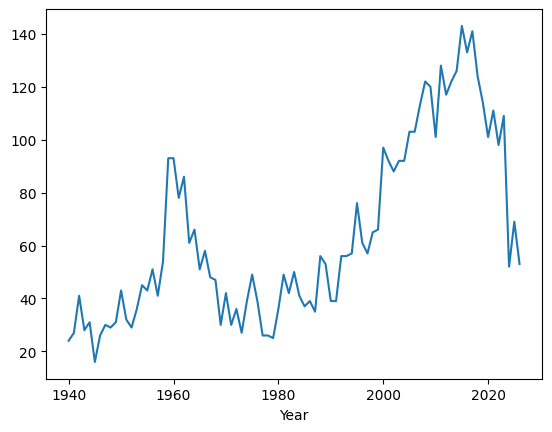

In [17]:
#2.3

var = 'Year'
print('Before cleaning:\n', df[var].describe(), '\n')
df[var]=pd.to_numeric(df[var], errors='coerce')

print('After cleaning: \n', df[var].describe(), '\n')
print('Minimum year:', df[var].min())
print('Maximum year:', df[var].max())

df_recent = df[df[var] >= 1940].copy()
attacks_by_year = df_recent.groupby(var).size()
attacks_by_year.plot()

#attacks are generally increasing over time especially from around 1980s-mid 2010s. there is a noticeable decline in recent years and are not remaining constant, but the overall pattern since 1940 is increasing

['?' '43' '27' '71' '21' '69' '31' '13' '12' '17' '35' "20's" '19' '11'
 '20' '38' '39' '16' '22' '30+' "50's" '55' '26' '56' '24' '25' '61' '40'
 '14' '50+' '54' '48' '57' '8' '63' '9' '7' '85' '18' '66' '37' '42' '45'
 '30' '60' '40+' '29' 35 58 29 24 20 55 17 12 37 36 23 40 28 69 48 '60+'
 57 45 61 27 38 16 68 33 30 15 41 14 43 26 'Middle age' 18 21 49 25 46 19
 65 64 nan '46' '32' '10' '64' '62' '15' '52' '44' '47' '59' '50' '34'
 '30s' '20/30' '65' '20s' '77' '49' '!2' '73' '50s' '58' '67' '6' '41'
 '53' '68' '51' 39 51 10 13 60 '40s' 62 'teen' 8 22 32 56 'Teen' 42 50 'M'
 9 31 11 34 '!6' '!!' 47 7 71 59 53 54 75 '45 and 15' 73 52 70 4 63 44
 '28 & 22' '22, 57, 31' '60s' 67 74 '9 & 60' 'a minor' 6 3 82 '40?' 66 72
 '23' '36' '70' '18 months' '28' '33' '74' '3' '28 & 26' '5' '86'
 '18 or 20' '12 or 13' '46 & 34' '28, 23 & 30' 'Teens' 77 '36 & 26'
 '8 or 10' 84 '\xa0 ' ' ' '30 or 36' '6½' '21 & ?' '33 or 37' 'mid-30s'
 '23 & 20' 5 ' 30' '7      &    31' ' 28' '20?' "60's" '32 & 30'


<Axes: >

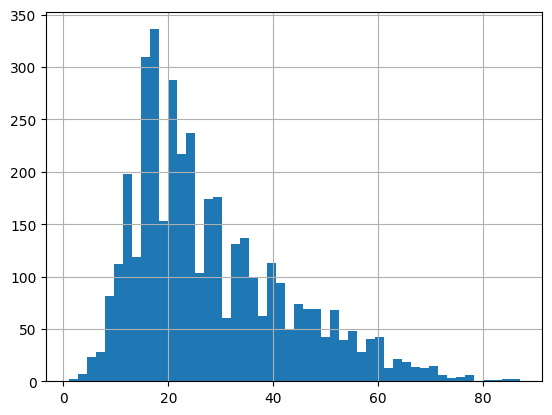

In [18]:
#2.4

var = 'Age'
print(df[var].unique(),'\n')
df['Age_clean']=(
    df[var]
    .astype('string')
    .str.strip()
)

df['Age_clean'] = pd.to_numeric(df['Age_clean'], errors='coerce')

print(df['Age_clean'].describe())
print('Total missing ages:', df['Age_clean'].isna().sum())
df['Age_clean'].hist(bins=50)

In [19]:
#2.5

print(df['Sex'].value_counts(dropna=False))
df['Sex_clean']=(
    df['Sex']
    .astype('string')
    .str.strip()
    .str.upper()
)

df['Sex_clean'] = df['Sex_clean'].where(
    df['Sex_clean'].isin(['M','F'])
)

male_prop = (df['Sex_clean'] == 'M').mean()
print('Proportion male:', male_prop)
print('Percent male:', round(male_prop * 100, 1))

Sex
M        5704
F         816
NaN       578
M           7
?           2
N           2
F           2
M F         1
 M          1
m           1
lli         1
M x 2       1
.           1
Name: count, dtype: int64
Proportion male: 0.8747511866482928
Percent male: 87.5


In [21]:
#2.6

print(df['Type'].value_counts(dropna=False))

df['Type_clean'] = (
    df['Type']
    .astype('string')
    .str.strip()
    .str.title()
)

df['Type_clean'] = df['Type_clean'].where(
    df['Type_clean'].isin(['Provoked', 'Unprovoked']),
    'Unknown'
)

print(df['Type_clean'].value_counts(dropna=False))

unprovoked_prop = (df['Type_clean'] == 'Unprovoked').mean()

print('Proportion unprovoked:', unprovoked_prop)
print('Percent unprovoked:', round(unprovoked_prop * 100, 1))

Type
Unprovoked             5261
Provoked                647
Invalid                 552
Watercraft              355
Sea Disaster            242
Questionable             27
NaN                      18
Boat                      7
 Provoked                 2
UNprovoked                1
unprovoked                1
Unconfirmed               1
?                         1
Unverified                1
Under investigation       1
Name: count, dtype: int64
Type_clean
Unprovoked    5263
Unknown       1205
Provoked       649
Name: count, dtype: Int64
Proportion unprovoked: 0.7394969790642124
Percent unprovoked: 73.9


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [2]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]